# AI Smart Energy Audit - 4 Case Studies Analysis
This notebook evaluates the Isolation Forest (Anomaly Detection) and Random Forest (Power-Delta Prediction) models across four distinct grid scenarios:
1. **Low Voltage**
2. **Normal Grid Supply**
3. **Demand = Supply** (Net Zero)
4. **PVe + Normal Grid**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)

try:
    rf_model = joblib.load('rf_power_model.pkl')
    rf_scaler = joblib.load('rf_power_scaler.pkl')
    iso_model = joblib.load('iso_model.pkl')
    iso_scaler = joblib.load('iso_scaler.pkl')
    print('✅ ML Models loaded successfully.')
except Exception as e:
    print(f'❌ Error loading models: {e}. Make sure you run if.py and rf.py first!')


✅ ML Models loaded successfully.


In [2]:
def evaluate_and_plot(case_name, df):
    print(f'\n========== {case_name} ==========')
    dfd = df.copy()
    # Feature Engineering exactly as in production (Deltas)
    dfd['delta_v'] = dfd['voltage'].diff().fillna(0)
    dfd['delta_i'] = dfd['current'].diff().fillna(0)
    dfd['delta_p'] = dfd['power'].diff().fillna(0)
    features = dfd[['delta_v', 'delta_i', 'delta_p']].values

    # 1. Isolation Forest Predict
    try:
        iso_scaled = iso_scaler.transform(features)
        preds = iso_model.predict(iso_scaled) # -1 is anomaly, 1 is normal
        anomalies = (preds == -1)
    except:
        anomalies = np.zeros(len(df), dtype=bool)

    dfd['is_anomaly'] = anomalies
    print(f'Isolation Forest Output: Detected {anomalies.sum()} anomalies out of {len(df)} samples.')

    # Plotting
    fig, ax = plt.subplots(3, 1, sharex=True, figsize=(12, 10))
    fig.suptitle(f'{case_name} - Telemetry & Anomalies', fontsize=16)

    # Voltage
    ax[0].scatter(dfd.index, dfd['voltage'], color='#3498db', s=10, label='Voltage (V)')
    ax[0].set_ylabel('Voltage (V)')
    ax[0].legend(loc='upper right')

    # Current
    ax[1].scatter(dfd.index, dfd['current'], color='#e67e22', s=10, label='Current (A)')
    ax[1].set_ylabel('Current (A)')
    ax[1].legend(loc='upper right')

    # Power & Scatter anomalies
    ax[2].scatter(dfd.index, dfd['power'], color='#2ecc71', s=10, label='Real Power (W)')
    anomaly_points = dfd[dfd['is_anomaly']]
    if not anomaly_points.empty:
        # Highlight anomalies
        ax[2].scatter(anomaly_points.index, anomaly_points['power'], 
                      color='red', s=80, edgecolors='black', zorder=5, label='Detected Anomaly')
    ax[2].set_ylabel('Real Power (W)')
    ax[2].set_xlabel('Time (samples)')
    ax[2].legend(loc='upper right')

    plt.tight_layout()
    safe_name = case_name.replace(' ', '_').replace(':', '').replace('=', '_')
    # Save the figure to disk as a PNG
    plt.savefig(f'{safe_name}.png', dpi=150)
    plt.show()

    return dfd


### Case 1: Low Voltage
Simulating a grid that is under strain, consistently supplying around 200V with intermittent severe drops. Let's capture how models perceive the rapid shift.



========== Case 1: Low Voltage Grid ==========
Isolation Forest Output: Detected 28 anomalies out of 120 samples.


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


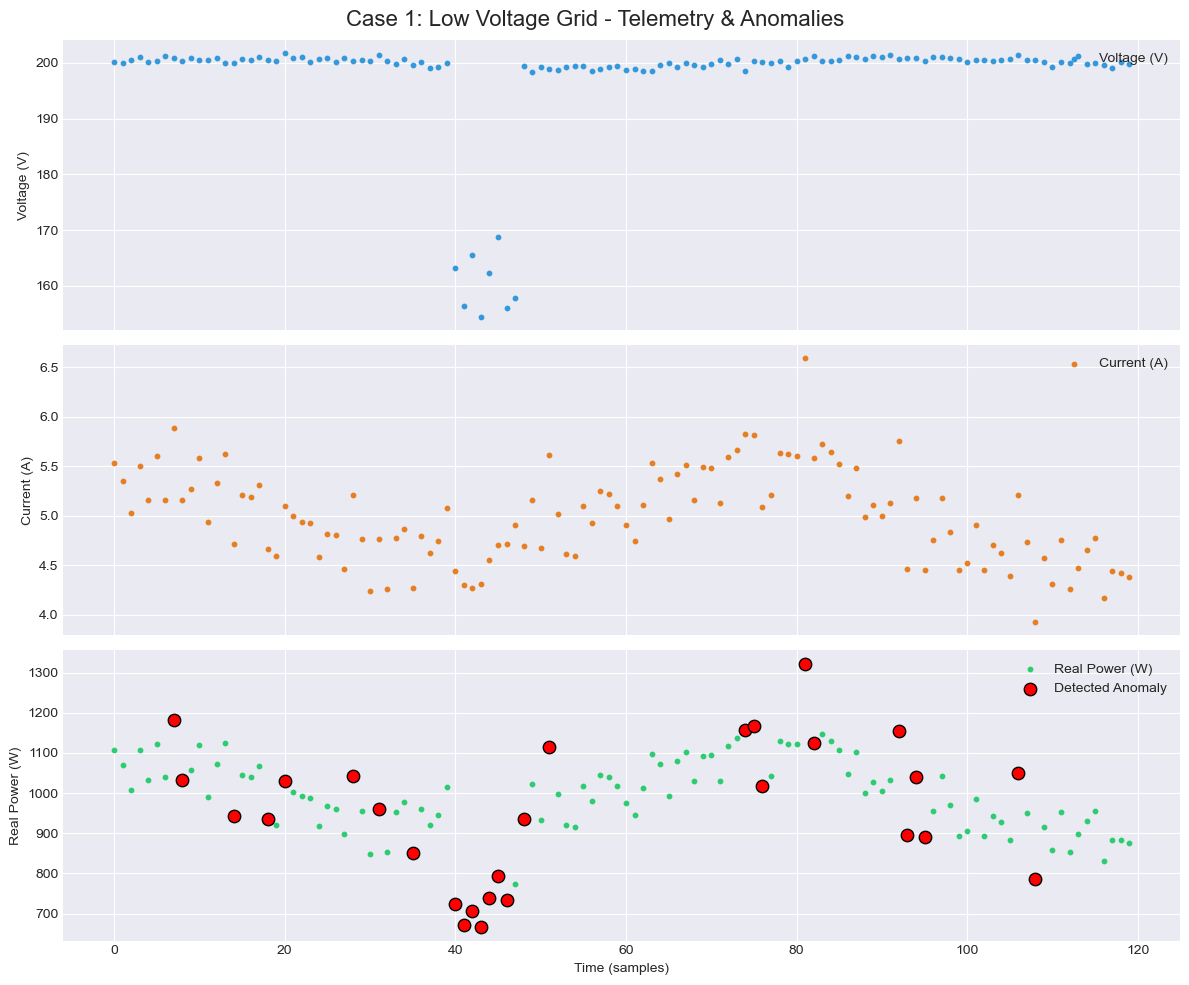

In [3]:
np.random.seed(42)
n = 120
t = np.linspace(0, 10, n)
v_low = 200 + np.sin(t) + np.random.normal(0, 0.5, n)
# Severe instantaneous voltage dip (sag) mid-run
v_low[40:48] = np.random.normal(160, 4, 8)

i_low = 5 + 0.5 * np.cos(t) + np.random.normal(0, 0.3, n)
p_low = v_low * i_low

df_case1 = pd.DataFrame({'voltage': v_low, 'current': i_low, 'power': p_low})
res1 = evaluate_and_plot('Case 1: Low Voltage Grid', df_case1)


### Case 2: Normal Grid Supply
Standard household 230V mains with typical residential load cycles. A heavy load (e.g., compressor / air conditioner) suddenly engages.



========== Case 2: Normal Grid Supply ==========
Isolation Forest Output: Detected 9 anomalies out of 120 samples.


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


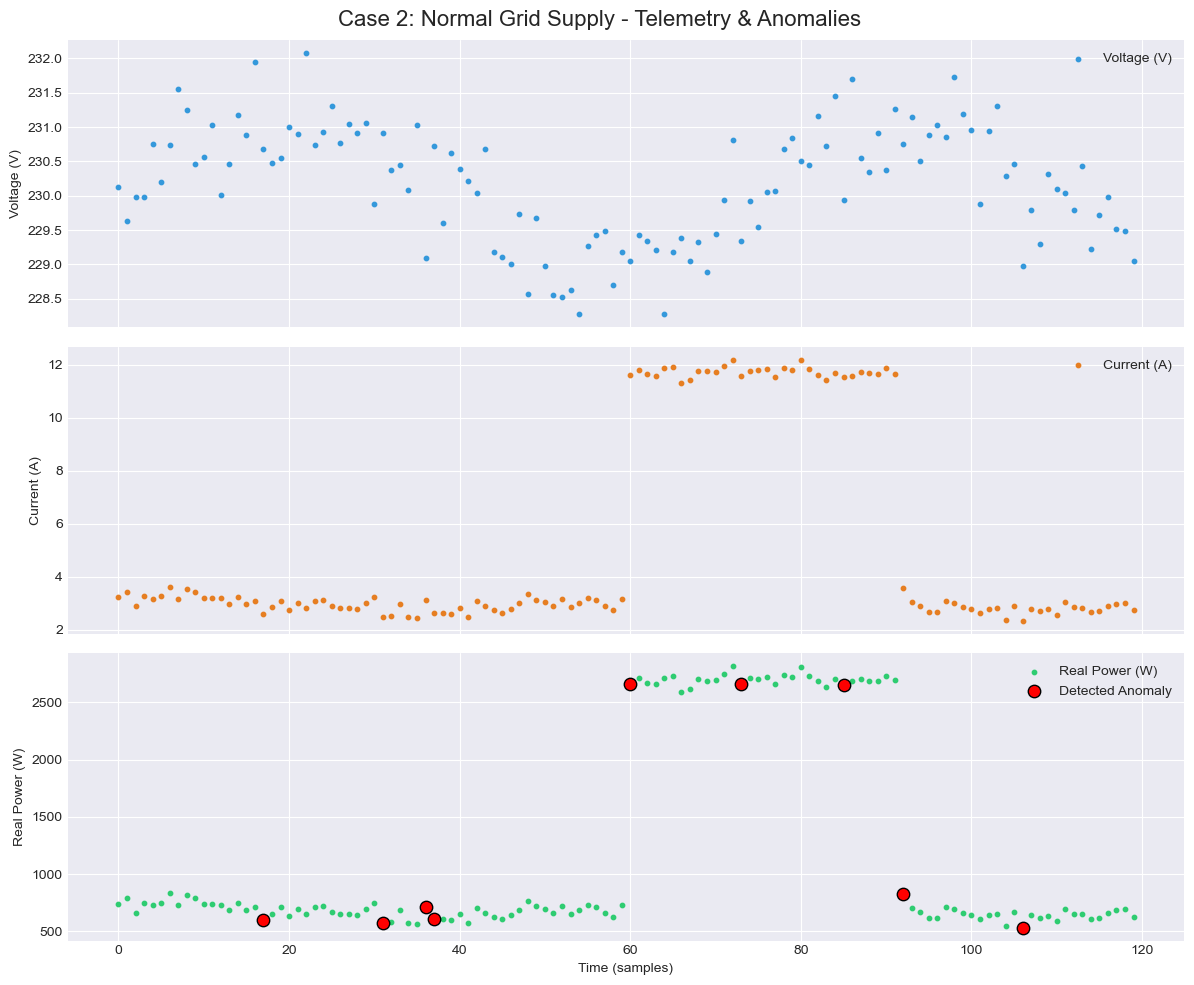

In [4]:
np.random.seed(43)
v_norm = 230 + np.sin(t) + np.random.normal(0, 0.5, n)
i_norm = 3 + 0.3 * np.cos(t) + np.random.normal(0, 0.2, n)
# Air-conditioner compressor kicks in sharply
i_norm[60:92] += 8.5

p_norm = v_norm * i_norm

df_case2 = pd.DataFrame({'voltage': v_norm, 'current': i_norm, 'power': p_norm})
res2 = evaluate_and_plot('Case 2: Normal Grid Supply', df_case2)


### Case 3: Demand = Supply
A steady state (Microgrid/Net Zero environment) where local generation (battery/solar) perfectly balances household demand. Meaning the net current off the main external supply effectively floats at zero Watts, barring very minor mismatches.



========== Case 3: Demand = Supply ==========
Isolation Forest Output: Detected 7 anomalies out of 120 samples.


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


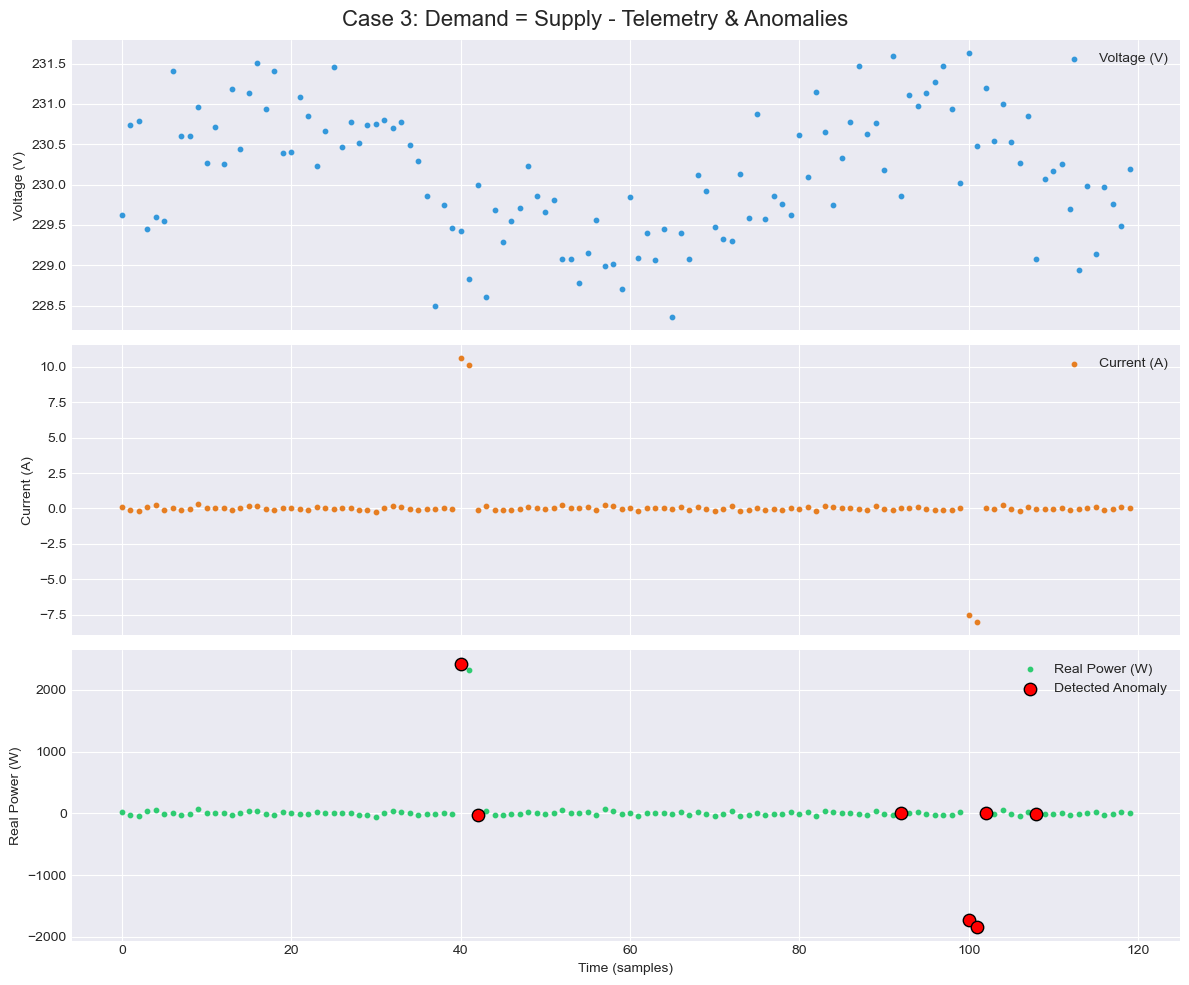

In [5]:
np.random.seed(44)
v_bal = 230 + np.sin(t) + np.random.normal(0, 0.5, n)
# Flawless load balancing - Net current is roughly zero
i_bal = np.random.normal(0, 0.1, n)
# Very brief sudden mismatch spikes (Anomaly clearly visible!)
i_bal[40:42] = np.random.normal(10.5, 0.5, 2)
i_bal[100:102] = np.random.normal(-8.0, 0.5, 2)

p_bal = v_bal * i_bal

df_case3 = pd.DataFrame({'voltage': v_bal, 'current': i_bal, 'power': p_bal})
res3 = evaluate_and_plot('Case 3: Demand = Supply', df_case3)


### Case 4: PVe + Normal Grid
High solar penetration creating a 'Duck Curve'. During mid-day (solar peak), home demand drops while PV pushes massive power back into the grid (negative net load). Local grid voltage naturally rises due to power export. Intense cloud blocks suddenly kill PV capacity abruptly bringing net load massively positive (returning to import).



========== Case 4: PVe + Normal Grid ==========
Isolation Forest Output: Detected 29 anomalies out of 120 samples.


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


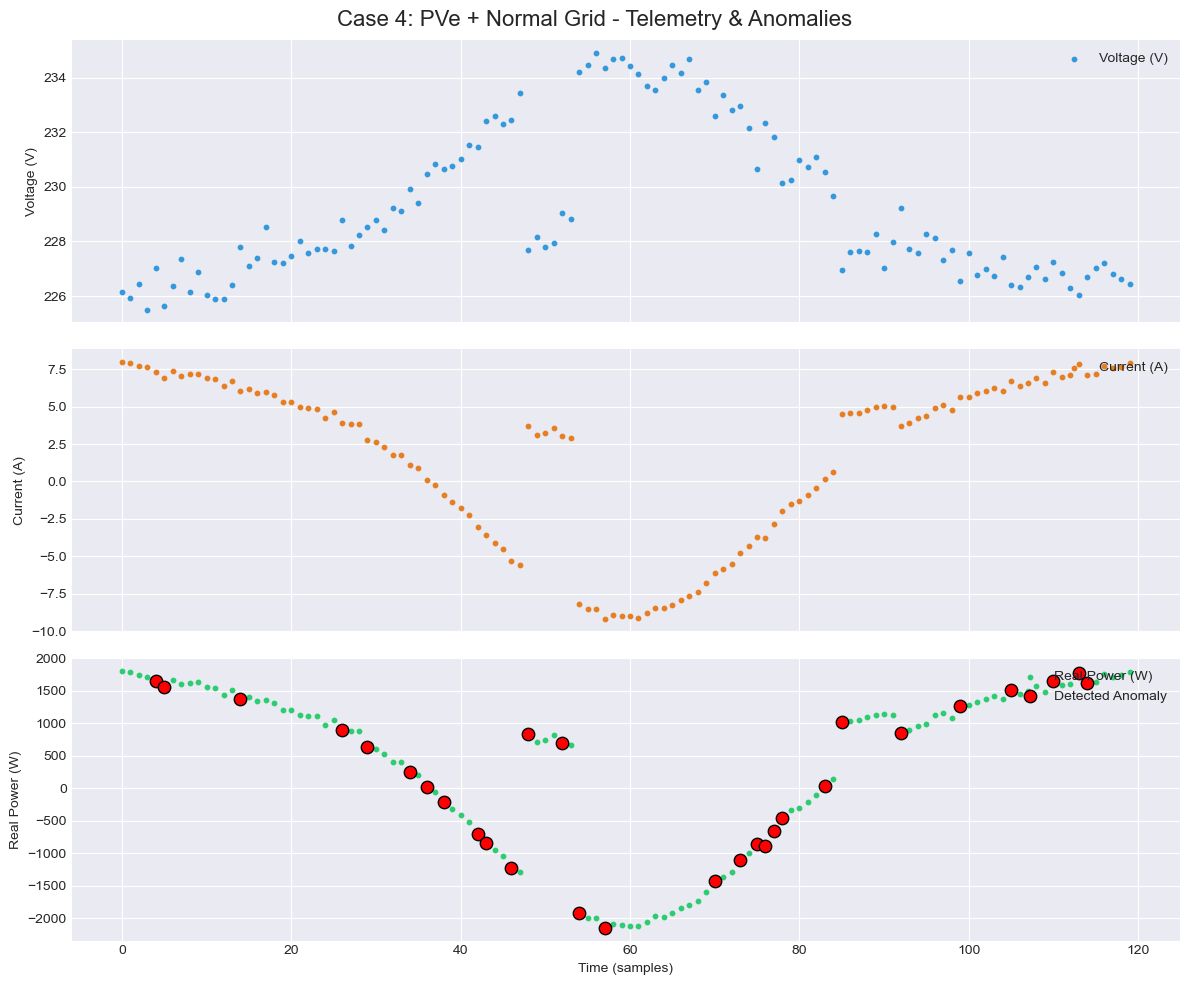

In [6]:
np.random.seed(45)
n = 120
# Realistic residential duck-curve load profile (higher morning & evening)
x = np.linspace(-1, 1, n)
house_demand = 5 + 3*(x**2) + np.random.normal(0, 0.2, n)

# Solar PV generation (bell curve, peaking mid-day)
pv_gen = 14 * np.exp(-(x*2.5)**2)

# Thick cloud completely knocks off solar output suddenly
pv_gen[48:54] *= 0.15 # 85% lost
pv_gen[85:92] *= 0.25 # 75% lost

# Negative Net means exporting back to external grid
i_pve = house_demand - pv_gen

# Local grid voltage actively rises when pushing negative amps back to grid
v_pve = 230 - (0.5 * i_pve) + np.random.normal(0, 0.5, n)
p_pve = v_pve * i_pve

df_case4 = pd.DataFrame({'voltage': v_pve, 'current': i_pve, 'power': p_pve})
res4 = evaluate_and_plot('Case 4: PVe + Normal Grid', df_case4)


### Conclusion: All Cases Combined
A single visual summary chart comprising all four cases across voltage, current, and real power dimensions.


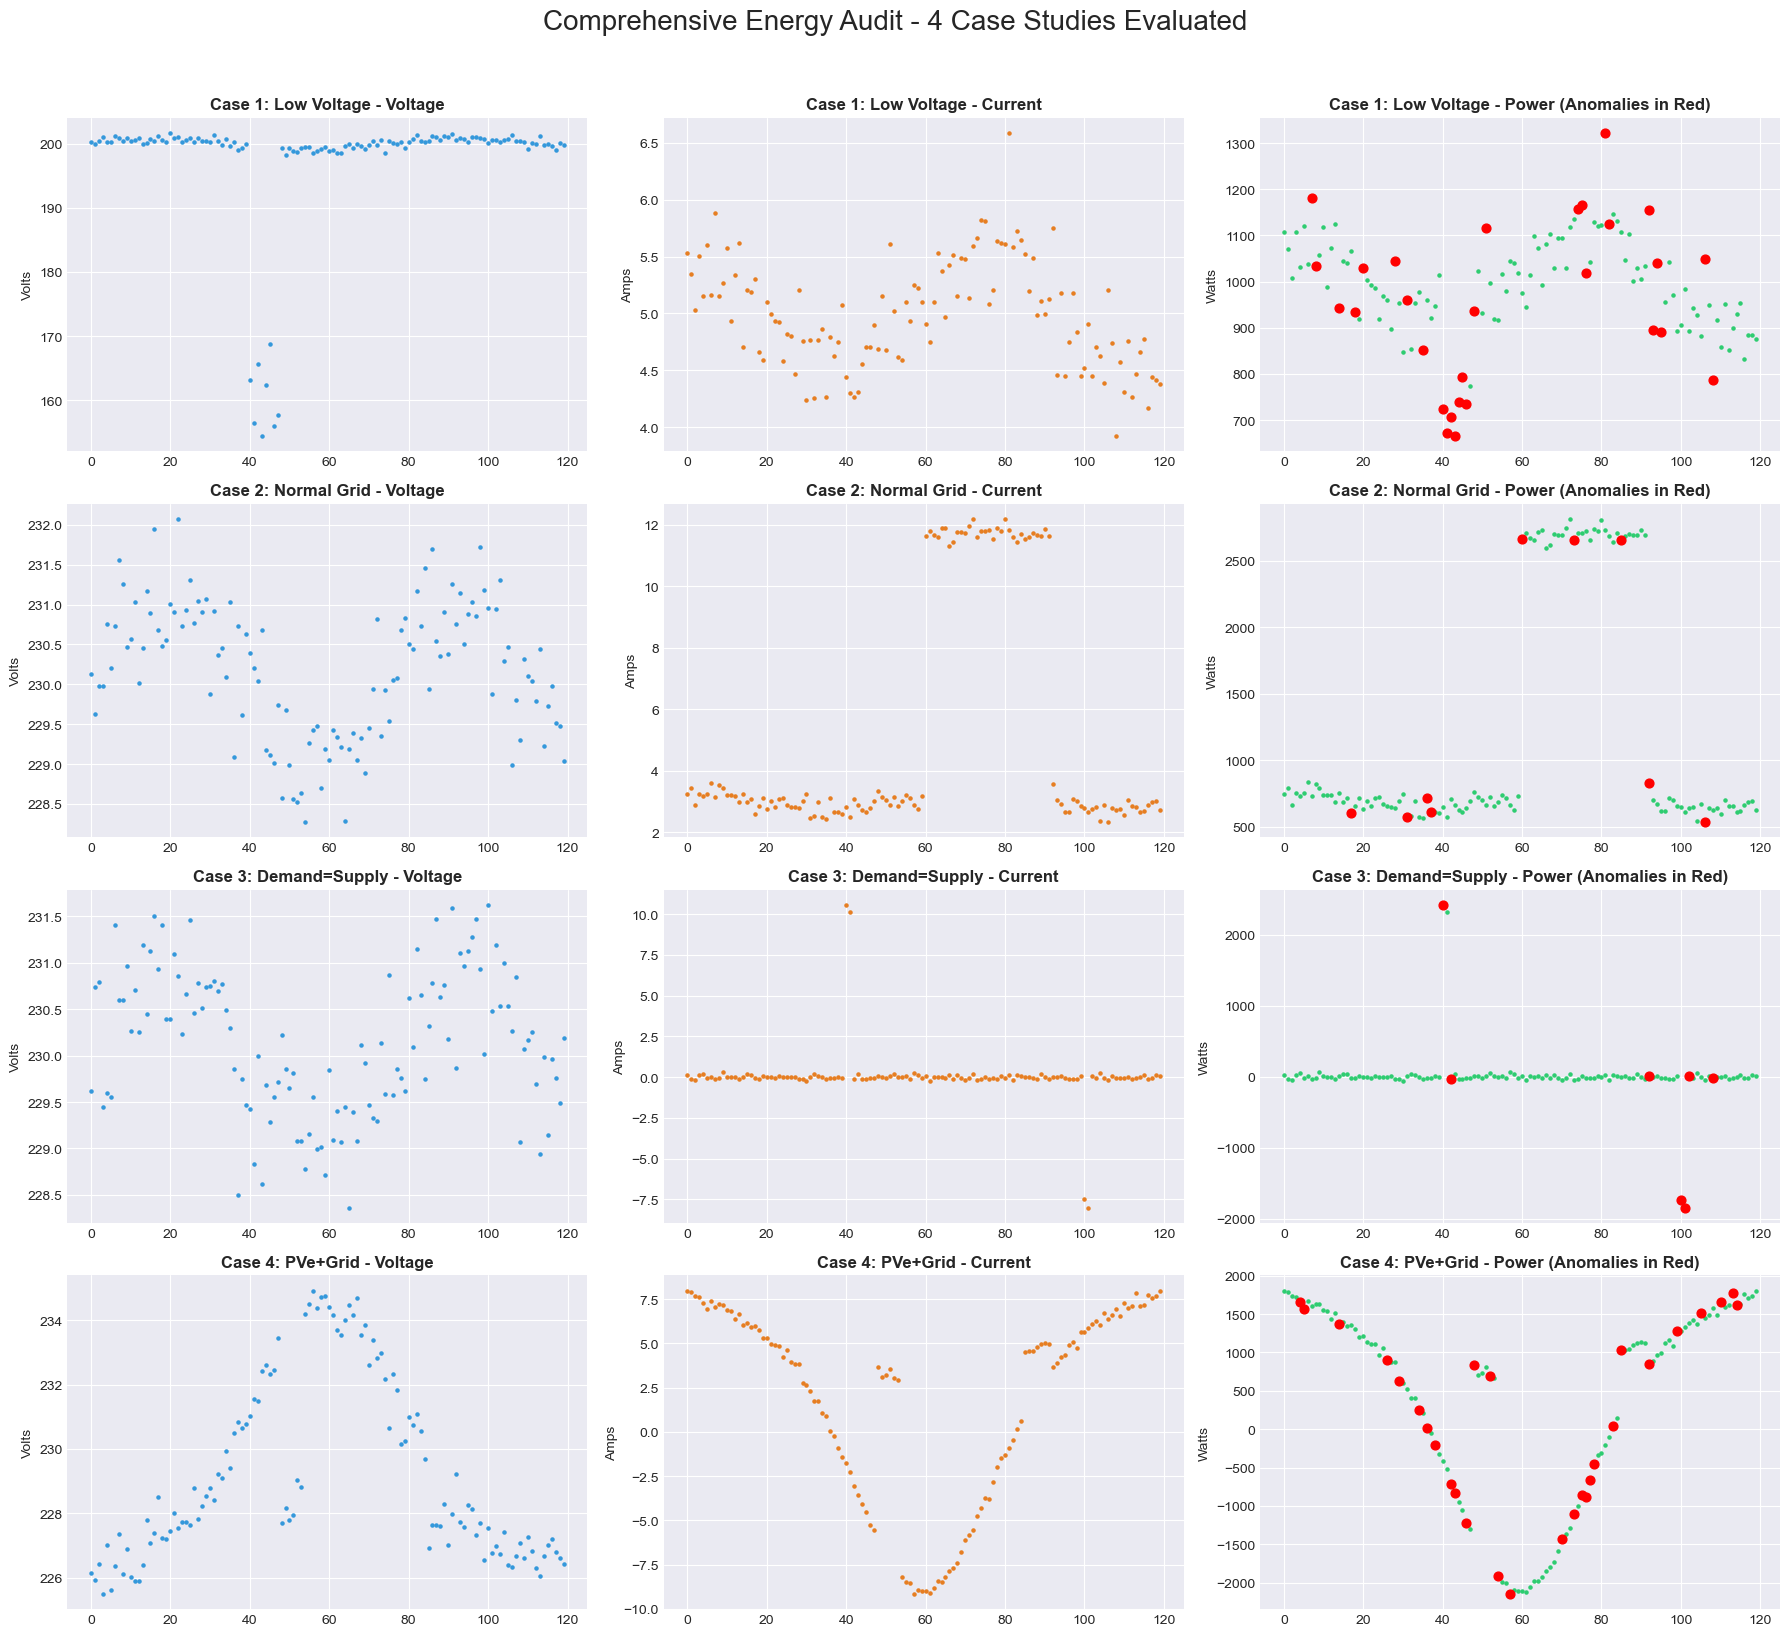

In [7]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
fig.suptitle('Comprehensive Energy Audit - 4 Case Studies Evaluated', fontsize=20, y=1.02)

datasets = [
    ('Case 1: Low Voltage', res1),
    ('Case 2: Normal Grid', res2),
    ('Case 3: Demand=Supply', res3),
    ('Case 4: PVe+Grid', res4)
]

for i, (name, df_case) in enumerate(datasets):
    # Voltage
    axes[i, 0].scatter(df_case.index, df_case['voltage'], color='#3498db', s=5)
    axes[i, 0].set_title(f'{name} - Voltage', fontweight='bold')
    axes[i, 0].set_ylabel('Volts')

    # Current
    axes[i, 1].scatter(df_case.index, df_case['current'], color='#e67e22', s=5)
    axes[i, 1].set_title(f'{name} - Current', fontweight='bold')
    axes[i, 1].set_ylabel('Amps')

    # Power
    axes[i, 2].scatter(df_case.index, df_case['power'], color='#2ecc71', s=5)
    anoms = df_case[df_case['is_anomaly']]
    if not anoms.empty:
        axes[i, 2].scatter(anoms.index, anoms['power'], color='red', s=40, zorder=5)
    axes[i, 2].set_title(f'{name} - Power (Anomalies in Red)', fontweight='bold')
    axes[i, 2].set_ylabel('Watts')

plt.tight_layout()
plt.savefig('combined_case_studies_summary.png', dpi=200, bbox_inches='tight')
plt.show()
